In [19]:
import sys
import numpy as np
from numpy import random as rd
import matplotlib.pyplot as plt
from matplotlib.animation import PillowWriter
from matplotlib.animation import FuncAnimation

In [20]:
def Random_walk(dimension,epochs,step_size = 1,starting_point = None):

    "This function generates a random walk in a given number of dimensions."
    "first give the dimension of the walk"
    "then give the number of epochs"
    "then give the step size"
    "then give the starting point"
    "the function will return a list of the positions of the walk"
    
    dimension_list=[]
    if starting_point is not None:
        if len(starting_point) == int(dimension):
            position = starting_point
        else:
            print("dimension of the starting point must be equal to dimension's of the walk :(")
            sys.exit()
    else:
        position = [0]*int(dimension)
    if type(step_size) != int:
        print("step size must be an integer :(")
        sys.exit()
    else:
        pass
        
    for dim in range(int(dimension)):
        dimension_list.append([])
        
    for epoch in range(epochs):
        direction = rd.randint(0,(int(dimension)))
        position[direction] = position[direction]+ rd.choice([-1*step_size,1*step_size])
        
        for dim in range(int(dimension)):
            dimension_list[dim].append(position[dim])
        
    return dimension_list

In [ ]:
def animate_walkers(walkers_list, dimension=2, interval=25, save_gif=False, filename='animation.gif'):
    
    "Creates an animated visualization of multiple random walkers with visible trails."
    "walkers_list: list of walker trajectories (each walker is output from Random_walk)"
    "dimension: 2 -> 2D plot, 3 -> 3D plot"
    "interval: delay between frames"
    "save_gif: whether to save animation as GIF"
    "filename: name of the GIF"
    
    margin = 5
    
    if dimension == 2:
        fig, ax = plt.subplots(figsize=(10, 10))
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.grid(True)
        
        all_x = np.concatenate([walker[0] for walker in walkers_list])
        all_y = np.concatenate([walker[1] for walker in walkers_list])
        x_min, x_max = all_x.min() - margin, all_x.max() + margin
        y_min, y_max = all_y.min() - margin, all_y.max() + margin
        
        def update(frame):
            ax.clear()
            ax.set_xlabel('X')
            ax.set_ylabel('Y')
            ax.grid(True)
            for walker in walkers_list:
                ax.plot(walker[0][:frame], walker[1][:frame], alpha=0.6, linewidth=1.5)
                if frame > 0:
                    ax.scatter(walker[0][frame-1], walker[1][frame-1], s=50, zorder=5)
            ax.set_xlim(x_min, x_max)
            ax.set_ylim(y_min, y_max)
            ax.set_title(f'Random Walkers 2D - Step {frame-1}')
            
        max_steps = len(walkers_list[0][0])
        anim = FuncAnimation(fig, update, frames=range(1, max_steps, 100), interval=interval)
        
        if save_gif:
            anim.save(filename, writer=PillowWriter(fps=30))
            print(f"GIF saved as {filename}")
        
        plt.show()
        
    elif dimension == 3:
        fig = plt.figure(figsize=(10, 10))
        ax = fig.add_subplot(111, projection='3d')
        ax.grid(True)
        all_x = np.concatenate([walker[0] for walker in walkers_list])
        all_y = np.concatenate([walker[1] for walker in walkers_list])
        all_z = np.concatenate([walker[2] for walker in walkers_list])
        x_min, x_max = all_x.min() - margin, all_x.max() + margin
        y_min, y_max = all_y.min() - margin, all_y.max() + margin
        z_min, z_max = all_z.min() - margin, all_z.max() + margin
        ax.view_init(elev=20, azim=-35)
        
        def update(frame):
            ax.clear()
            ax.set_xlabel('X')
            ax.set_ylabel('Y')
            ax.set_zlabel('Z')
            ax.grid(True)
            for walker in walkers_list:
                ax.plot(walker[0][:frame], walker[1][:frame], walker[2][:frame], alpha=0.6, linewidth=1.5)
                if frame > 0:
                    ax.scatter(walker[0][frame-1], walker[1][frame-1], walker[2][frame-1], s=50, zorder=5)
            ax.set_xlim(x_min, x_max)
            ax.set_ylim(y_min, y_max)
            ax.set_zlim(z_min, z_max)
            ax.set_title(f'Random Walkers 3D - Step {frame-1}')
            
        max_steps = len(walkers_list[0][0])
        anim = FuncAnimation(fig, update, frames=range(1, max_steps, 100), interval=interval)
        
        if save_gif:
            anim.save(filename, writer=PillowWriter(fps=30))
            print(f"GIF saved as {filename}")
        
        plt.show()

    elif dimension >= 4:
        print("Dude, this is not 4D chess!, GROW UP!!")

In [73]:
starting_points_2d = [[5, 5],[5, 0],[0, 5],[10, 5],[5, 10],[2, 2],[8, 8],[8, 2],[2, 8],[5, -3]]
walkers_list_2d = [Random_walk(2, 10100, 1, coordination) for coordination in starting_points_2d]

In [74]:
starting_points_3d = [[-3, 2, 5],[12, -1, 8],[7, 14, 4],[-2, 9, -4],[15, 5, 11],[4, -5, 6],[9, 13, -2],[-1, 3, 12],[6, -3, 14],[11, 7, -1]]
walkers_list_3d = [Random_walk(3, 10100, 1, coordination) for coordination in starting_points_3d]

GIF saved as random_walkers_2d_interval_5_10_walkers.gif


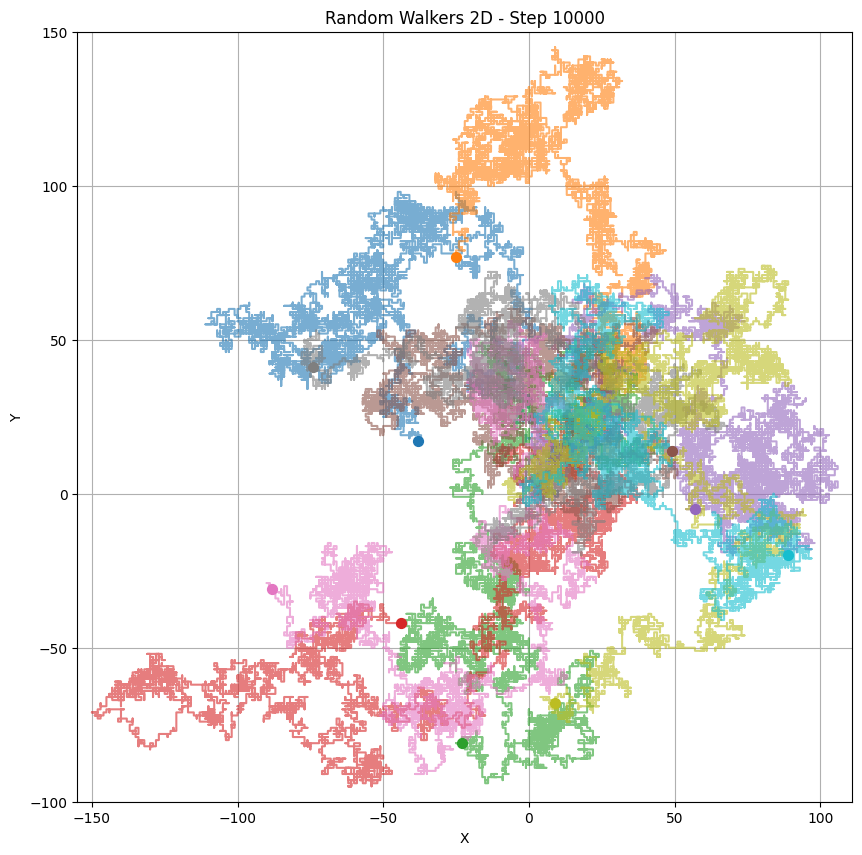

In [75]:
interval = 5
animate_walkers(walkers_list_2d, dimension=2, save_gif=True, interval=5, filename=f'random_walkers_2d_interval_{interval}_{len(walkers_list_2d)}_walkers.gif')

GIF saved as random_walkers_3d_interval_5_10_walkers.gif


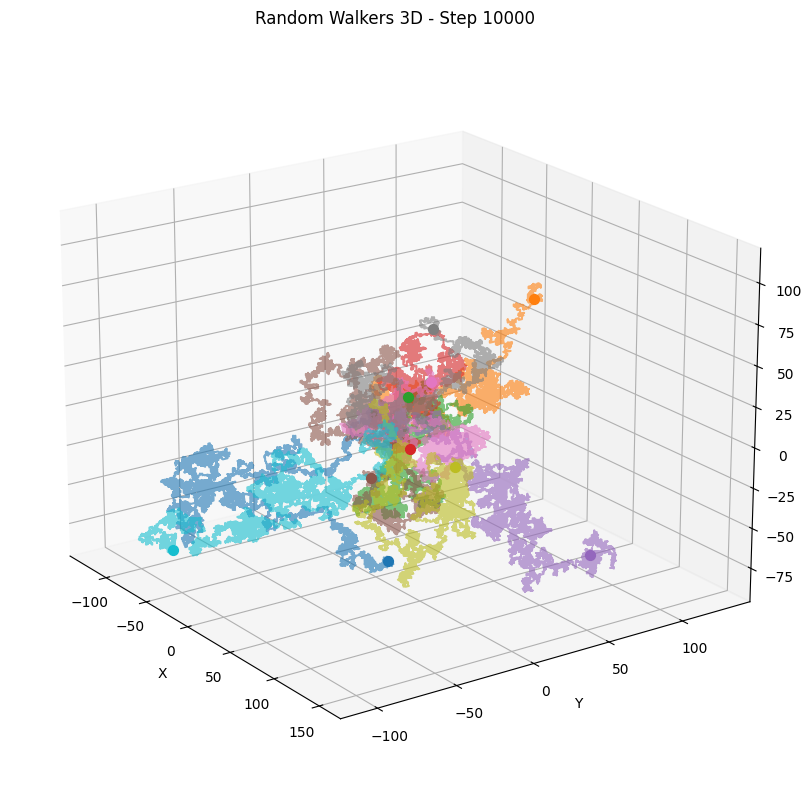

In [76]:
interval = 5
animate_walkers(walkers_list_3d, dimension=3, save_gif=True, interval=5, filename=f'random_walkers_3d_interval_{interval}_{len(walkers_list_3d)}_walkers.gif')